# Hospital Length-of-Stay Prediction — Exploratory Data Analysis

**Goal**: understand the UCI *Diabetes 130-US Hospitals (1999–2008)* dataset before building a predictive model of inpatient length of stay (LOS).

Data: 101,766 inpatient encounters from 130 US hospitals (real-world EHR, widely used in academic research). Target: `time_in_hospital` (days).

Reference: Strack et al. (2014), *Impact of HbA1c Measurement on Hospital Readmission Rates*.

In [1]:
import sys
from pathlib import Path
# locate the repository root robustly: works when the kernel runs from
# the repo root OR from inside notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from src.config import RAW_DATA_PATH
from src.data_utils import clean_data, load_raw_data

df_raw = load_raw_data()
df = clean_data(df_raw)
print(f'raw   : {df_raw.shape}')
print(f'clean : {df.shape}')
df.head()

raw   : (101766, 50)
clean : (101766, 26)


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,readmitted,age_years,diag_1_cat,diag_2_cat,diag_3_cat,med_count,visit_history_total,is_discharge_unusual,max_glu_serum_level,a1c_level
0,Caucasian,Female,6,25,1,1,Pediatrics-Endocrinology,41,0,1,...,NO,5,Neoplasm,Unknown,Unknown,0,0,0,0,0
1,Caucasian,Female,1,1,7,3,NaN,59,0,18,...,>30,15,Neoplasm,Neoplasm,Neoplasm,1,0,0,0,0
2,AfricanAmerican,Female,1,1,7,2,NaN,11,5,13,...,NO,25,Nervous,Neoplasm,Health_Status,1,3,0,0,0
3,Caucasian,Male,1,1,7,2,NaN,44,1,16,...,NO,35,Respiratory,Neoplasm,Blood,1,0,0,0,0
4,Caucasian,Male,1,1,7,1,NaN,51,0,8,...,NO,45,Infectious,Infectious,Neoplasm,2,0,0,0,0


## 1. Cleaning decisions
- Dropped `encounter_id` / `patient_nbr` (identifiers) and `weight` (~97% missing), `payer_code` (~40% missing, low signal).
- `age` bins converted to numeric midpoints.
- ICD-9 diagnosis codes collapsed into 19 clinical categories.
- 23 diabetes-medication indicator columns aggregated into `med_count`.
- Prior-visit columns aggregated into `visit_history_total`.

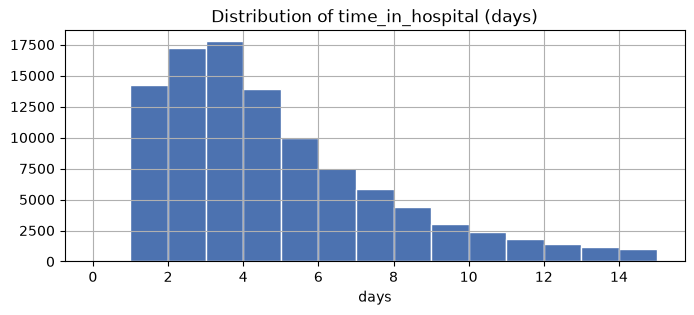

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 3))
df['time_in_hospital'].hist(bins=range(0, 16), ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of time_in_hospital (days)')
ax.set_xlabel('days')
plt.show()
print(df['time_in_hospital'].describe())

In [4]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing[missing > 0]

medical_specialty    49.082208
race                  2.233555
dtype: float64

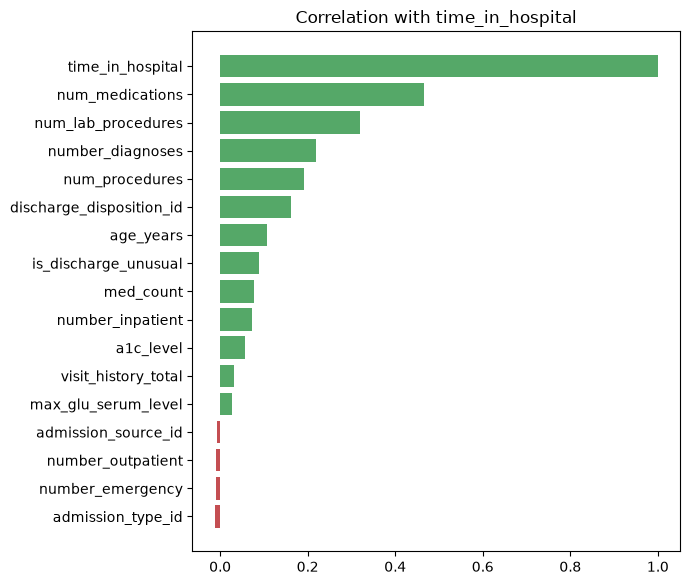

In [5]:
num_cols = [c for c in df.columns if df[c].dtype in ('int64', 'float64')]
corr = df[num_cols].corrwith(df['time_in_hospital']).sort_values()
fig, ax = plt.subplots(figsize=(7, max(3, len(corr) * 0.35)))
colors = ['#C44E52' if v < 0 else '#55A868' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title('Correlation with time_in_hospital')
plt.tight_layout(); plt.show()

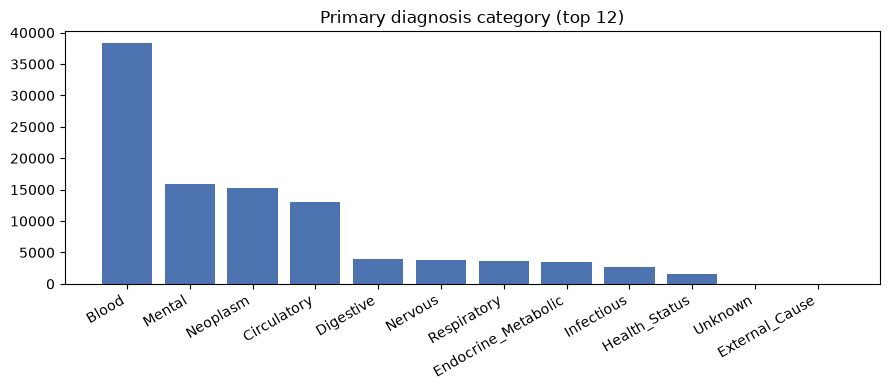

In [6]:
top = df['diag_1_cat'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(top)), top.values, color='#4C72B0')
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=30, ha='right')
ax.set_title('Primary diagnosis category (top 12)')
plt.tight_layout(); plt.show()

## Key takeaways (from a full run)
- LOS is heavily right-skewed (median 3 days); log-transform helps.
- Clinical workload (`num_lab_procedures`, `num_medications`, `number_diagnoses`) correlates most strongly with LOS.
- Circulatory / Endocrine / Respiratory diagnoses dominate this cohort.